> **Setup notebook — not part of `scripts/run_phase1.py`.**
> One-shot audit that produced `backend/data/processed/coverage_audit.csv`
> and the `osm_empty` / `osm_partial` / `osm_good` classification
> that drove Phase 1C effort. Re-run only if the OSM extract changes
> or the scoring thresholds need recalibration.

# Phase 1A.2 — OSM Coverage Audit

Quantify what OSM has per Visayas province so Phase 1C scope is no longer a guess.

**Output:** `backend/data/processed/coverage_audit.csv` — one row per province with `transmission_score`, `distribution_score`, `submarine_present`, classification, notes.

**Scoring (0–3):**
- 0 = empty, 1 = sparse, 2 = partial, 3 = good (definitions per metric set in §3)

**Drives downstream classification:** `osm_good` (dist_score ≥ 2), `osm_partial` (dist_score = 1), `osm_empty` (dist_score = 0).

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import geopandas as gpd

RAW = Path('../backend/data/raw/visayas_power_raw.geojson')
BOUND_DIR = Path('../backend/data/boundaries')
PROC_DIR = Path('../backend/data/processed')
PROC_DIR.mkdir(parents=True, exist_ok=True)

gdf = gpd.read_file(RAW)
provinces = gpd.read_file(BOUND_DIR / 'psgc_provinces.geojson')
islands = gpd.read_file(BOUND_DIR / 'visayas_islands.geojson')
print(f'OSM features: {len(gdf)} | Provinces: {len(provinces)} | Islands: {len(islands)}')

/Users/julius/polymath/Projects/powergrid/.venv/lib/python3.14/site-packages/pyogrio/raw.py:200: RuntimeWarning: Several features with id = 1237981974 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


OSM features: 19607 | Provinces: 16 | Islands: 9


## §1 — Voltage parsing

OSM `voltage` tags are messy: numeric strings (`'138000'`), multi-voltage (`'138000;69000'`), junk (`'220_-_25000_Watts...'`), or missing. Parse each row to a list of valid voltages in kV.

In [2]:
def parse_voltage(v) -> list[int]:
    if v is None or (isinstance(v, float) and pd.isna(v)):
        return []
    s = str(v)
    out = []
    for part in re.split(r'[;,/]', s):
        m = re.search(r'\d+', part)
        if not m:
            continue
        n = int(m.group())
        # OSM convention: voltages stored in volts. Some tags use kV; we accept both.
        kv = n / 1000 if n >= 1000 else n  # 138000 → 138 ; 138 → 138
        # Drop implausible values (sub-LV junk, mis-tagged Watts, etc.)
        if 0.4 <= kv <= 1000:
            out.append(int(round(kv)))
    return out

gdf['voltage_kv_list'] = gdf['voltage'].apply(parse_voltage)
gdf['voltage_kv_max'] = gdf['voltage_kv_list'].apply(lambda xs: max(xs) if xs else None)

TRANSMISSION_KV = {69, 138, 230, 350, 500}
DISTRIBUTION_KV = {13, 14, 23, 24, 33, 34, 35}  # 13.2/13.8/23/34.5 rounded

def classify(vlist):
    if not vlist:
        return 'unknown'
    vmax = max(vlist)
    if vmax in TRANSMISSION_KV or vmax > 60:
        return 'transmission'
    if vmax in DISTRIBUTION_KV or 10 <= vmax <= 50:
        return 'distribution'
    return 'lv'

gdf['vclass'] = gdf['voltage_kv_list'].apply(classify)
print('Voltage class × power tag:')
print(pd.crosstab(gdf['power'], gdf['vclass']))

Voltage class × power tag:
vclass      distribution  lv  transmission  unknown
power                                              
cable                  0   0            33       11
line                   9  22           343      215
substation             0   0            46       75
tower                  0   0             0    18853


## §2 — Subset to the things that matter for coverage

Lines + cables only. Towers are inferred bus locations (Phase 1B). Substations counted separately.

In [3]:
lines = gdf[gdf['power'].isin(['line', 'cable'])].copy()
subs = gdf[gdf['power'] == 'substation'].copy()

lines = lines[lines.geometry.geom_type.isin(['LineString', 'MultiLineString'])]

tx = lines[lines['vclass'] == 'transmission'].copy()
dx = lines[lines['vclass'] == 'distribution'].copy()
uk = lines[lines['vclass'] == 'unknown'].copy()
submarine = lines[lines['power'] == 'cable'].copy()

print(f'Lines total: {len(lines)}')
print(f'  Transmission (≥69 kV-ish): {len(tx)}')
print(f'  Distribution (10-50 kV): {len(dx)}')
print(f'  Unknown voltage: {len(uk)}')
print(f'  Submarine cables (power=cable): {len(submarine)}')
print(f'Substations: {len(subs)}')

Lines total: 631
  Transmission (≥69 kV-ish): 374
  Distribution (10-50 kV): 9
  Unknown voltage: 226
  Submarine cables (power=cable): 44
Substations: 121


## §3 — Spatial join: lines → province, with length in km

Lines can cross provinces (a 138 kV backbone touches multiple). Use `predicate='intersects'` so a line contributes to every province it touches; clip geometry per province to get true intra-province length.

In [4]:
PROV_M = provinces.to_crs(32651)  # UTM 51N for metric length

def per_province_lengths(line_gdf: gpd.GeoDataFrame) -> pd.Series:
    if len(line_gdf) == 0:
        return pd.Series({p: 0.0 for p in provinces['province']})
    g = line_gdf.to_crs(32651)
    # Clip each line to each province, sum lengths
    joined = gpd.overlay(
        g[['geometry']].assign(_idx=range(len(g))),
        PROV_M[['province', 'geometry']],
        how='intersection', keep_geom_type=False
    )
    joined = joined[joined.geometry.geom_type.isin(['LineString', 'MultiLineString'])]
    joined['length_km'] = joined.geometry.length / 1000
    s = joined.groupby('province')['length_km'].sum()
    return s.reindex(provinces['province'], fill_value=0.0)

tx_km = per_province_lengths(tx)
dx_km = per_province_lengths(dx)
uk_km = per_province_lengths(uk)
print('Transmission line-km per province:')
print(tx_km.sort_values(ascending=False).to_string())

Transmission line-km per province:
province
Leyte                1889.693639
Cebu                 1789.283209
Samar                1275.646335
Negros Occidental     386.933743
Bohol                 380.242604
Northern Samar        272.226812
Negros Oriental       142.789648
Southern Leyte         83.895161
Iloilo                 42.176764
Aklan                   0.000000
Antique                 0.000000
Biliran                 0.000000
Capiz                   0.000000
Eastern Samar           0.000000
Guimaras                0.000000
Siquijor                0.000000


In [5]:
# Substation count per province (point/polygon centroid join)
subs_pt = subs.copy()
subs_pt['geometry'] = subs_pt.geometry.representative_point()
sj = gpd.sjoin(subs_pt, provinces[['province', 'geometry']], how='left', predicate='within')
subs_count = sj.groupby('province').size().reindex(provinces['province'], fill_value=0)
print('Substations per province:')
print(subs_count.sort_values(ascending=False).to_string())

Substations per province:
province
Cebu                 43
Leyte                19
Negros Occidental    12
Bohol                 9
Negros Oriental       9
Samar                 8
Northern Samar        3
Southern Leyte        3
Eastern Samar         2
Biliran               1
Iloilo                1
Siquijor              1
Aklan                 0
Antique               0
Capiz                 0
Guimaras              0


In [6]:
# Submarine cable presence per province (any intersection)
if len(submarine) > 0:
    sub_m = submarine.to_crs(32651)
    sub_join = gpd.sjoin(sub_m, PROV_M[['province', 'geometry']], how='left', predicate='intersects')
    submarine_provinces = set(sub_join['province'].dropna())
else:
    submarine_provinces = set()
print('Provinces with submarine cable touching:', sorted(submarine_provinces))

Provinces with submarine cable touching: ['Bohol', 'Cebu', 'Eastern Samar', 'Leyte', 'Negros Occidental', 'Negros Oriental', 'Northern Samar', 'Southern Leyte']


## §4 — Per-province scoring (0–3)

**Transmission score** (uses line-km + substation count):
- 0: 0 km transmission AND 0 substations
- 1: < 30 km OR < 2 substations
- 2: < 150 km AND ≥ 2 substations
- 3: ≥ 150 km AND ≥ 3 substations

**Distribution score** (uses line-km only):
- 0: 0 km
- 1: < 50 km
- 2: 50–500 km
- 3: ≥ 500 km

Thresholds are coarse on purpose — the audit just needs to bucket each province into "empty / sparse / partial / good" so Phase 1C can decide effort. Adjust if the resulting classification looks wrong at the decision point.

In [7]:
def score_tx(km: float, n_subs: int) -> int:
    if km == 0 and n_subs == 0:
        return 0
    if km >= 150 and n_subs >= 3:
        return 3
    if km >= 30 and n_subs >= 2:
        return 2
    return 1

def score_dx(km: float) -> int:
    if km == 0:
        return 0
    if km >= 500:
        return 3
    if km >= 50:
        return 2
    return 1

def classify_phase1c(dx_score: int) -> str:
    return {0: 'osm_empty', 1: 'osm_partial', 2: 'osm_good', 3: 'osm_good'}[dx_score]

audit_rows = []
for _, row in provinces.iterrows():
    p = row['province']
    tx_len = tx_km[p]
    dx_len = dx_km[p]
    uk_len = uk_km[p]
    n_subs = int(subs_count[p])
    sub_present = p in submarine_provinces
    ts = score_tx(tx_len, n_subs)
    ds = score_dx(dx_len)
    notes = []
    if uk_len > 0.5 * max(tx_len + dx_len, 1):
        notes.append(f'untagged_voltage_km={uk_len:.0f}')
    if sub_present:
        notes.append('submarine_cable')
    audit_rows.append({
        'psgc_code': row['psgc_code'],
        'province': p,
        'island_name': row['island_name'],
        'transmission_km': round(tx_len, 1),
        'distribution_km': round(dx_len, 1),
        'unknown_km': round(uk_len, 1),
        'substation_count': n_subs,
        'transmission_score': ts,
        'distribution_score': ds,
        'submarine_present': sub_present,
        'phase1c_class': classify_phase1c(ds),
        'notes': '; '.join(notes),
    })

audit = pd.DataFrame(audit_rows).sort_values(
    ['island_name', 'province']
).reset_index(drop=True)
audit

,psgc_code,province,island_name,transmission_km,distribution_km,unknown_km,substation_count,transmission_score,distribution_score,submarine_present,phase1c_class,notes
0,0878000000,Biliran,Biliran,0.0,0.0,0.0,1,1,0,False,osm_empty,
1,0712000000,Bohol,Bohol,380.2,0.0,0.4,9,3,0,True,osm_empty,submarine_cable
2,0722000000,Cebu,Cebu,1789.3,0.0,27.2,43,3,0,True,osm_empty,submarine_cable
3,0679000000,Guimaras,Guimaras,0.0,0.0,0.0,0,0,0,False,osm_empty,
4,0837000000,Leyte,Leyte,1889.7,0.1,72.6,19,3,1,True,osm_partial,submarine_cable
5,0864000000,Southern Leyte,Leyte,83.9,0.1,0.6,3,2,1,True,osm_partial,submarine_cable
6,0645000000,Negros Occidental,Negros,386.9,0.0,0.1,12,3,0,True,osm_empty,submarine_cable
7,0746000000,Negros Oriental,Negros,142.8,0.0,16.3,9,2,0,True,osm_empty,submarine_cable
8,0604000000,Aklan,Panay,0.0,0.0,0.0,0,0,0,False,osm_empty,
9,0606000000,Antique,Panay,0.0,0.0,0.0,0,0,0,False,osm_empty,


## §5 — Per-island summary

In [8]:
island_summary = (
    audit.groupby('island_name')
    .agg(
        provinces=('province', 'count'),
        tx_km=('transmission_km', 'sum'),
        dx_km=('distribution_km', 'sum'),
        substations=('substation_count', 'sum'),
        any_submarine=('submarine_present', 'any'),
    )
    .reset_index()
)
island_summary

,island_name,provinces,tx_km,dx_km,substations,any_submarine
0,Biliran,1,0.0,0.0,1,False
1,Bohol,1,380.2,0.0,9,True
2,Cebu,1,1789.3,0.0,43,True
3,Guimaras,1,0.0,0.0,0,False
4,Leyte,2,1973.6,0.2,22,True
5,Negros,2,529.7,0.0,21,True
6,Panay,4,42.2,0.0,1,False
7,Samar,3,1547.8,0.0,13,True
8,Siquijor,1,0.0,0.0,1,False


In [9]:
phase1c_counts = audit['phase1c_class'].value_counts()
print('Phase 1C scope by province count:')
print(phase1c_counts.to_string())
print()
print('Decision drivers:')
for cls in ['osm_empty', 'osm_partial', 'osm_good']:
    matches = audit[audit['phase1c_class'] == cls]['province'].tolist()
    print(f'  {cls} ({len(matches)}): {matches}')

Phase 1C scope by province count:
phase1c_class
osm_empty      12
osm_partial     4

Decision drivers:
  osm_empty (12): ['Biliran', 'Bohol', 'Cebu', 'Guimaras', 'Negros Occidental', 'Negros Oriental', 'Aklan', 'Antique', 'Capiz', 'Iloilo', 'Eastern Samar', 'Siquijor']
  osm_partial (4): ['Leyte', 'Southern Leyte', 'Northern Samar', 'Samar']
  osm_good (0): []


## §6 — Visual smoke test

Lines colored by class, on the province polygons. Sanity-check that transmission backbone visibly traces Cebu/Negros/Panay/Leyte-Samar.

/var/folders/55/ht5rdwd56fxfdm_8v_0bxfrc0000gn/T/ipykernel_78400/1941178320.py:9: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc='upper right')


Text(204.83034902640762, 0.5, 'Latitude')

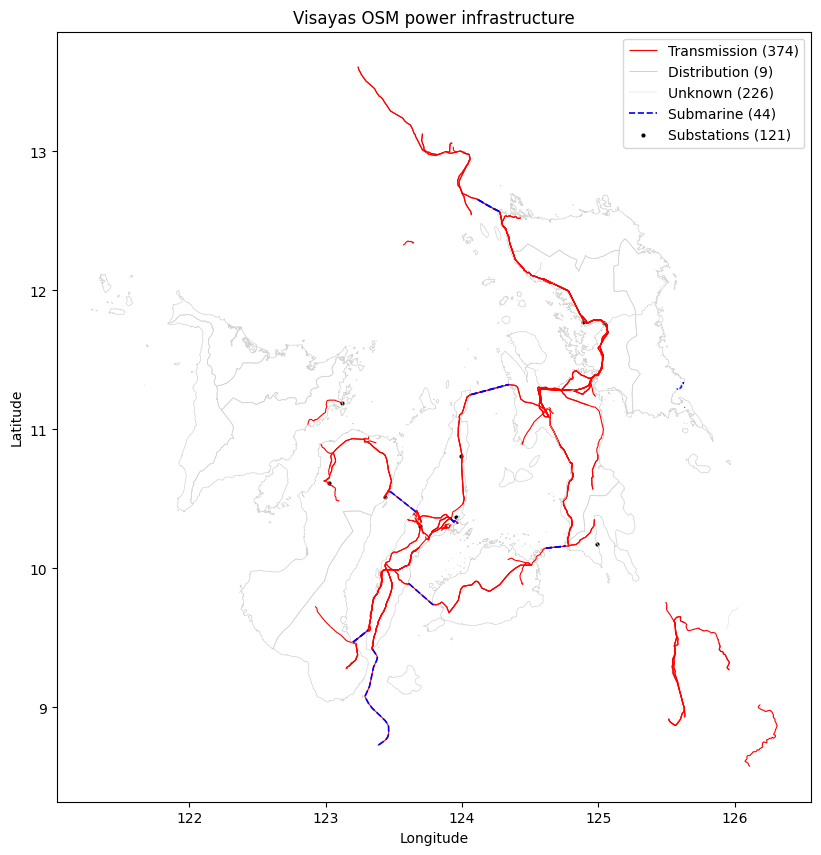

In [10]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 10))
provinces.boundary.plot(ax=ax, color='lightgrey', linewidth=0.5)
if len(tx):  tx.plot(ax=ax, color='red',    linewidth=0.8, label=f'Transmission ({len(tx)})')
if len(dx):  dx.plot(ax=ax, color='orange', linewidth=0.4, label=f'Distribution ({len(dx)})')
if len(uk):  uk.plot(ax=ax, color='lightgrey', linewidth=0.3, label=f'Unknown ({len(uk)})')
if len(submarine): submarine.plot(ax=ax, color='blue', linewidth=1.2, linestyle='--', label=f'Submarine ({len(submarine)})')
if len(subs): subs.plot(ax=ax, color='black', markersize=4, label=f'Substations ({len(subs)})')
ax.legend(loc='upper right')
ax.set_title('Visayas OSM power infrastructure')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

## §7 — Save audit table

Phase 1B uses `submarine_present` and `substation_count` for sanity checks; Phase 1C consumes `phase1c_class` per province.

In [11]:
out = PROC_DIR / 'coverage_audit.csv'
audit.to_csv(out, index=False)
print(f'Wrote {out} ({len(audit)} rows)')

Wrote ../backend/data/processed/coverage_audit.csv (16 rows)
